In [1]:
import sys

sys.path.append("..")

import os

from dotenv import load_dotenv

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [2]:
from app.core.config import get_settings
from app.core.models import load_shared_models
from app.domain.fulfillment.model_registry import load_fulfillment_models
from app.domain.nlp.model_registry import load_nlp_models
from app.domain.nlp.service import get_intent
from app.domain.rag.model_registry import load_rag_models
from app.domain.rag.service import support_agent
from app.domain.vision.model_registry import load_vision_models

settings = get_settings()
settings.vision_weights_path = "../models/shelf_detection_best.pt"
shared = load_shared_models(settings)

nlp_models = load_nlp_models(settings, shared)
rag_models = load_rag_models(settings, shared)
fulfillment_models = load_fulfillment_models(settings, shared)
vision_models = load_vision_models(settings, shared)

print("All four domains loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

All four domains loaded


In [3]:
from typing import Optional, TypedDict


class SupervisorState(TypedDict):
    query: str
    image_path: Optional[str]
    category: Optional[str]
    confidence: Optional[float]
    method: Optional[str]
    response: Optional[str]
    needs_image: bool

In [20]:
def classify_intent_node(state: SupervisorState) -> dict:
    result = get_intent(state["query"], nlp_models, settings)
    return {
        "category": result.category,
        "confidence": result.confidence,
        "method": result.method,
    }

In [21]:
def call_support_node(state: SupervisorState) -> dict:
    result = support_agent(state["query"], rag_models)
    return {"response": result.answer}

In [22]:
def call_fulfillment_node(state: SupervisorState) -> dict:
    result = fulfillment_models.agent.invoke({"messages": [("user", state["query"])]})
    answer = result["messages"][-1].content
    return {"response": answer}

In [23]:
def call_vision_node(state: SupervisorState) -> dict:
    if not state.get("image_path"):
        return {
            "needs_image": True,
            "response": "This looks like a shelf/inventory question, but I don't have an image to check. "
            "Please upload a shelf photo, or rephrase your question if you meant something else.",
        }

    message = f"Check the status of shelf image at {state['image_path']}"
    result = vision_models.agent.invoke({"messages": [("user", message)]})
    answer = result["messages"][-1].content
    return {"needs_image": False, "response": answer}

In [24]:
def route_by_category(state: SupervisorState) -> str:
    category = state["category"]
    if category == "support":
        return "call_support"
    elif category == "fulfillment":
        return "call_fulfillment"
    elif category == "vision":
        return "call_vision"
    else:
        return "call_support"

In [25]:
from langgraph.graph import StateGraph, END

builder = StateGraph(SupervisorState)

builder.add_node("classify_intent", classify_intent_node)
builder.add_node("call_support", call_support_node)
builder.add_node("call_fulfillment", call_fulfillment_node)
builder.add_node("call_vision", call_vision_node)

builder.set_entry_point("classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_by_category,
    {
        "call_support": "call_support",
        "call_fulfillment": "call_fulfillment",
        "call_vision": "call_vision",
    },
)

builder.add_edge("call_support", END)
builder.add_edge("call_fulfillment", END)
builder.add_edge("call_vision", END)

supervisor_graph = builder.compile()

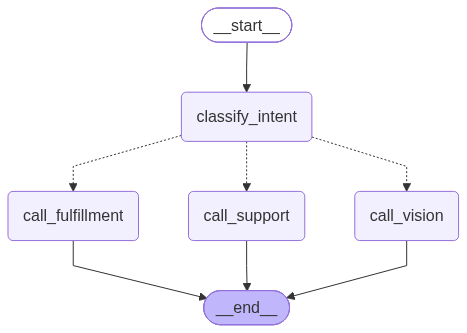

In [26]:
from IPython.display import Image, display

display(Image(supervisor_graph.get_graph().draw_mermaid_png()))

In [27]:
test_cases = [
    {"query": "What is your return policy for bread?", "image_path": None},
    {"query": "Is the wireless earbuds in stock?", "image_path": None},
    {"query": "Cancel order_003", "image_path": None},
    {
        "query": "Check shelf status",
        "image_path": None,
    },  # should trigger the missing-image path
    {
        "query": "Check shelf status",
        "image_path": "../models/test/shelf_test.jpg",
    },  # image provided
]

for case in test_cases:
    result = supervisor_graph.invoke(
        {
            "query": case["query"],
            "image_path": case["image_path"],
            "category": None,
            "confidence": None,
            "method": None,
            "response": None,
            "needs_image": False,
        }
    )
    print(f"\nQuery: {case['query']!r} (image: {case['image_path']})")
    print(f"Routed to: {result['category']}")
    print(f"Response: {result['response']}")


Query: 'What is your return policy for bread?' (image: None)
Routed to: support
Response: Bread is considered a perishable item, so it can’t be returned after purchase. However, if the loaf was spoiled or defective when you bought it, you can bring it back within 48 hours for a full refund or an exchange.

Query: 'Is the wireless earbuds in stock?' (image: None)
Routed to: fulfillment
Response: I’m sorry, but our wireless Bluetooth earbuds are currently out of stock. Let me know if you’d like to be notified when they’re back or if you’d like help finding a similar product!

Query: 'Cancel order_003' (image: None)
Routed to: fulfillment
Response: Your order **order_003** is already cancelled, so there’s nothing further to do. If you have any other requests or need assistance with a new order, just let me know!

Query: 'Check shelf status' (image: None)
Routed to: vision
Response: This looks like a shelf/inventory question, but I don't have an image to check. Please upload a shelf photo